**importing the dataset form kaggle**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


**Accessing the folders**

In [2]:
import os
os.listdir(path)

['seg_train', 'seg_pred', 'seg_test']

**Taking the training Testing and predictions data**

In [3]:
train_path=os.path.join(path,"seg_train","seg_train")
test_path=os.path.join(path,"seg_test","seg_test")
pred_path=os.path.join(path,"seg_pred","seg_pred")
print("Train path:",train_path)
print("Test path:",test_path)
print("Pred path:",pred_path)


Train path: /kaggle/input/intel-image-classification/seg_train/seg_train
Test path: /kaggle/input/intel-image-classification/seg_test/seg_test
Pred path: /kaggle/input/intel-image-classification/seg_pred/seg_pred


**checking the six classess**

In [4]:
classess=os.listdir(train_path)
print("classess:",classess)
print("Number of classess:",len(classess))

classess: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Number of classess: 6


**Importing tensorflow and keras**

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


**Counting the images in each class**

In [6]:
for class_name in classess:
  class_path=os.path.join(train_path,class_name)
  image_count=len(os.listdir(class_path))
  print(class_name,':',image_count,"Images")

mountain : 2512 Images
street : 2382 Images
buildings : 2191 Images
sea : 2274 Images
forest : 2271 Images
glacier : 2404 Images


**Checking the image size**

In [7]:
class_name=classess[0]
class_path=os.path.join(train_path,class_name)
image_name=os.listdir(class_path)[0]
image_path=os.path.join(class_path,image_name)
image=tf.io.read_file(image_path)
image=tf.image.decode_image(image,channels=3)
print("class:",class_name)
print("Image shape:",image.shape)

class: mountain
Image shape: (150, 150, 3)


**Displaying the sample images**

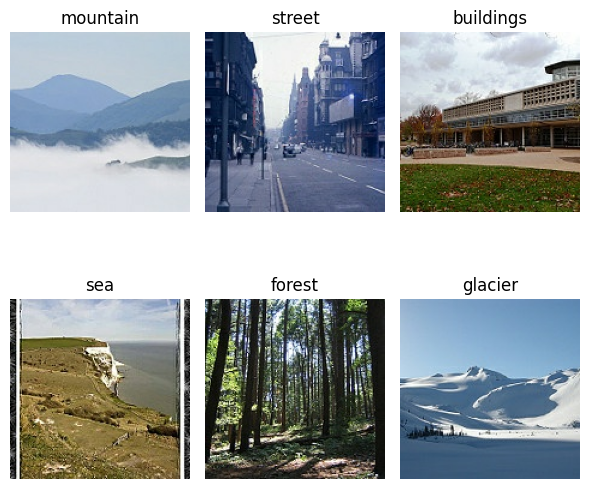

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
for i,class_name in enumerate(classess):
  class_path=os.path.join(train_path,class_name)
  image_name=os.listdir(class_path)[0]
  image_path=os.path.join(class_path,image_name)
  image=tf.io.read_file(image_path)
  image=tf.image.decode_image(image,channels=3)
  plt.subplot(2,3,i+1)
  plt.imshow(image)
  plt.title(class_name)
  plt.axis("off")
plt.tight_layout()
plt.show()


**Data preprocessing**

**create the training and validation datasets**

In [9]:
IMG_SIZE=(150,150)
BATCH_SIZE=32
train_ds=tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=123
)
val_ds=tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=123
)


Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


**Getting class names from the dataset**

In [10]:
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


**Creating test data**

In [11]:
test_ds=tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


**Normalizing the pixel values**

In [12]:
normalization_layer=tf.keras.layers.Rescaling(1./255)
train_ds=train_ds.map(lambda x,y:(normalization_layer(x),y))
val_ds=val_ds.map(lambda x,y:(normalization_layer(x),y))
test_ds=test_ds.map(lambda x,y:(normalization_layer(x),y))

**Checking normalization**

In [13]:
for images,labels in train_ds.take(1):
  print("Minimum pixel value:",tf.reduce_min(images).numpy())
  print("Maximum pixel value:",tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


**Data augmentation**

In [14]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1,0.1)
])

**Building the CNN model**

In [15]:
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150,150,3)),
    data_augmentation,
    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6,activation="softmax")
])




**Compiling the model**

In [16]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

**Adding Early stopping**

In [18]:
early_stopping=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)

**Fitting the model**

In [19]:
history=model.fit(train_ds,validation_data=val_ds,epochs=50,callbacks=[early_stopping])

Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.4445 - loss: 1.3819 - val_accuracy: 0.5723 - val_loss: 1.0631
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.5334 - loss: 1.1954 - val_accuracy: 0.5937 - val_loss: 1.0162
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.5778 - loss: 1.1206 - val_accuracy: 0.5745 - val_loss: 1.1439
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.5978 - loss: 1.0617 - val_accuracy: 0.6575 - val_loss: 0.9147
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6172 - loss: 1.0251 - val_accuracy: 0.6839 - val_loss: 0.8465
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6380 - loss: 0.9859 - val_accuracy: 0.6796 - val_loss: 0.8507
Epoch 7/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.6549 - loss: 0.9472 - val_accuracy: 0.7021 - val_loss: 0.7899
Epoch 8/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6589 - loss: 0.9355 - 

**Evaluating the model**

In [20]:
test_loss,test_accuracy=model.evaluate(test_ds)
print("Test loss:",test_loss)
print("Test accuracy:",test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7837 - loss: 0.5949
Test loss: 0.5948627591133118
Test accuracy: 0.7836666703224182


**Ploting training and validation accuracy/loss**

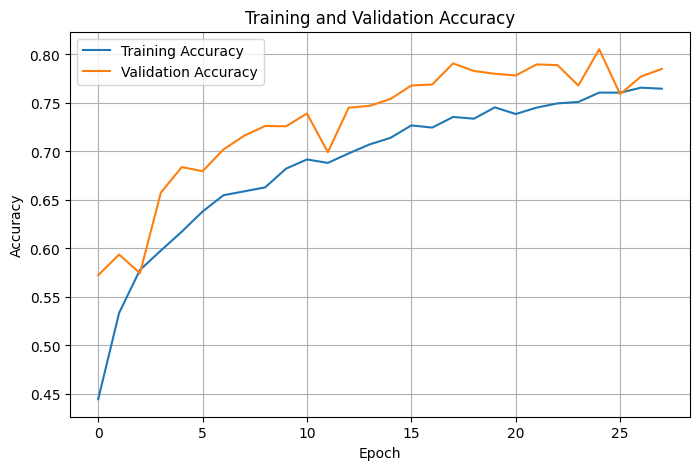

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

**ploting loss**

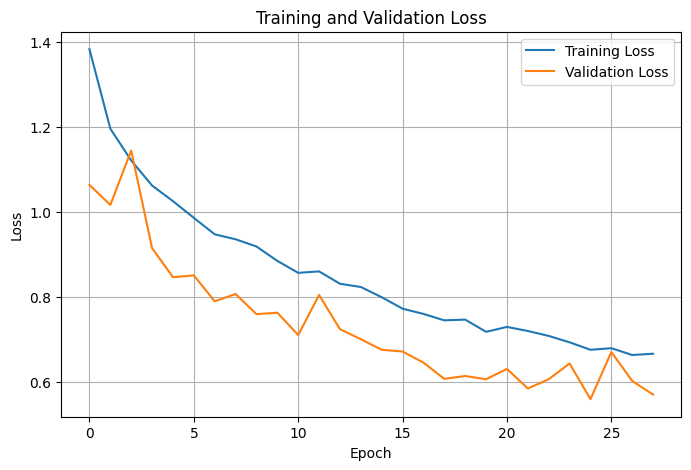

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Getting actual and predicted labels**

In [23]:
import numpy as np
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
print("Actual labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Actual labels: (3000,)
Predicted labels: (3000,)


**Finding precicion recall and F1 score**

In [24]:
from sklearn.metrics import classification_report
print(
    classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   buildings       0.77      0.62      0.69       437
      forest       0.91      0.96      0.94       474
     glacier       0.77      0.76      0.76       553
    mountain       0.76      0.70      0.73       525
         sea       0.74      0.76      0.75       510
      street       0.75      0.89      0.82       501

    accuracy                           0.78      3000
   macro avg       0.78      0.78      0.78      3000
weighted avg       0.78      0.78      0.78      3000



**Confusion matrix**

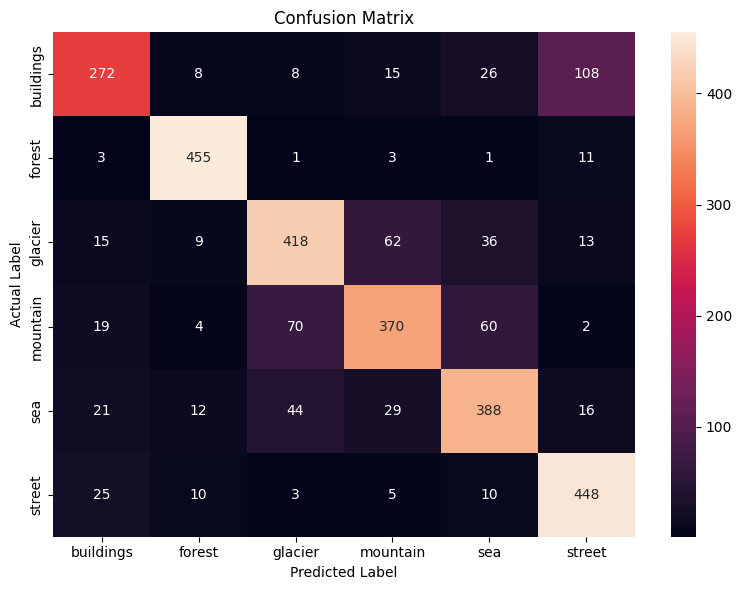

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

**Selecting 10 random test images**

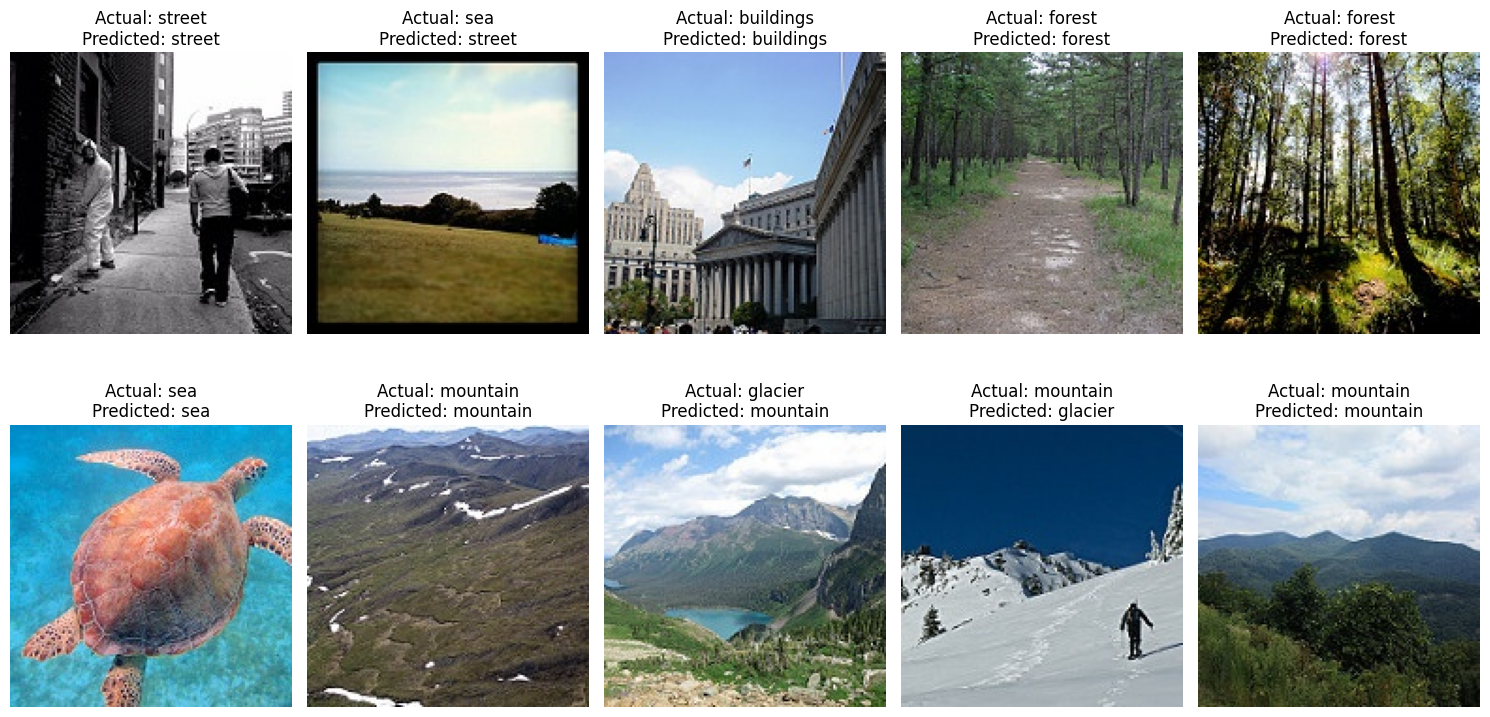

In [26]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Store all test image paths

test_images = []

for class_name in class_names:
    class_folder = os.path.join(test_path, class_name)

    for image_name in os.listdir(class_folder):
        image_path = os.path.join(class_folder, image_name)
        test_images.append((image_path, class_name))

# Select 10 random images

random_images = random.sample(test_images, 10)

# Display the images

plt.figure(figsize=(15, 8))

for i, (image_path, actual_label) in enumerate(random_images):

    # Load image

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    # Convert image to array

    image_array = tf.keras.utils.img_to_array(image)

    # Normalize

    image_array = image_array / 255.0

    # Add batch dimension

    image_input = np.expand_dims(
        image_array,
        axis=0
    )

    # Predict

    prediction = model.predict(
        image_input,
        verbose=0
    )

    predicted_index = np.argmax(
        prediction[0]
    )

    predicted_label = class_names[
        predicted_index
    ]

    # Display

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Actual: {actual_label}\n"
        f"Predicted: {predicted_label}"
    )

plt.tight_layout()
plt.show()

Predicted class: sea


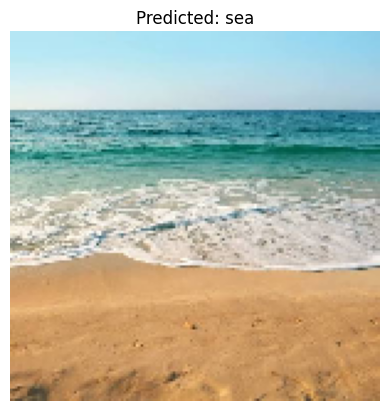

In [28]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

image_path = "/content/sea2.jpg"

# Load image

img = tf.keras.utils.load_img(
    image_path,
    target_size=(150, 150)
)

# Convert to array

img_array = tf.keras.utils.img_to_array(img)

# Normalize pixel values

img_array = img_array / 255.0

# Add batch dimension

img_array = np.expand_dims(
    img_array,
    axis=0
)

# Predict

prediction = model.predict(
    img_array,
    verbose=0
)

# Get predicted class index

predicted_class = np.argmax(
    prediction[0]
)

# Get class name

predicted_label = class_names[
    predicted_class
]

print("Predicted class:", predicted_label)

# Display

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Predicted: {predicted_label}"
)
plt.show()